In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, f1_score
from sklearn.ensemble import VotingClassifier

In [26]:
df = pd.read_csv('flood_risk_dataset_modified.csv')
df.head()

,county,nearest_town,town_size,landcover_types,elevation_m,dist_to_town_m,dist_to_water_m,topographic_hazard,landcover_risk,water_proximity_risk,vulnerability_score,flood_risk_score,risk_category
0,Migori,Mohoni,Town,waterbodies,1134.0,14191.648756,9.891734e+06,0.0,9.0,0,0.0,2.2,Very High Risk
1,Migori,Mohoni,Town,waterbodies,1134.0,16419.789667,9.898062e+06,0.0,9.0,0,0.0,2.2,Very High Risk
2,Migori,Nyatembe,Town,waterbodies,1134.0,18365.752928,9.904390e+06,0.0,9.0,0,0.0,2.2,Very High Risk
3,Migori,Nyandhiwa,Town,waterbodies,1134.0,13839.292053,9.910718e+06,0.0,9.0,0,0.0,2.2,Very High Risk
4,Homa Bay,Nyandhiwa,Town,waterbodies,1134.0,10562.446388,9.917045e+06,0.0,9.0,0,0.0,2.2,Very High Risk


In [27]:
# preprocessing

# label encoding for categorical variables
label_encoder = LabelEncoder()
df['county'] = label_encoder.fit_transform(df['county'])
df['nearest_town'] = label_encoder.fit_transform(df['nearest_town'])
df['town_size'] = label_encoder.fit_transform(df['town_size'])
df['landcover_types'] = label_encoder.fit_transform(df['landcover_types'])
df['risk_category'] = label_encoder.fit_transform(df['risk_category'])

In [28]:
# train-test split
#Drop the classification and highly correlated features with noise
X = df.drop(['risk_category','flood_risk_score','landcover_risk','landcover_types'], axis=1)

# target
y = df['risk_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# call random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)



In [30]:
# cross validation score
cv_scores_rf = cross_val_score(rf_classifier, X_train, y_train, cv=5)
print("Random Forest Classifier Cross-Validation Scores:", cv_scores_rf)
print("Random Forest Classifier Average CV Score:", np.mean(cv_scores_rf))


Random Forest Classifier Cross-Validation Scores: [0.77844828 0.78534483 0.79517033 0.78654592 0.79560155]
Random Forest Classifier Average CV Score: 0.7882221825697758


In [31]:
# evaluate the random forest classifier

print("Random Forest Classifier Evaluation:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf, average='weighted') * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))





Random Forest Classifier Evaluation:
Accuracy: 79.66%
F1 Score: 79.64%

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.67      0.70       747
           1       0.74      0.79      0.76       623
           2       0.71      0.78      0.74       281
           3       0.89      0.88      0.89      1249

    accuracy                           0.80      2900
   macro avg       0.77      0.78      0.77      2900
weighted avg       0.80      0.80      0.80      2900



**Insights for Random Forest Classifier Evaluation:**  
The model achieves 80% accuracy with strong performance on class 3 (very high risk), indicating reliability for identifying critical flood areas. However, lower precision for class 0 (0.72) suggests over-classification of low-risk areas as higher risk, which is conservative but may lead to unnecessary alerts. The macro average F1 of 0.77 reflects balanced handling across classes, though minority class 2 could benefit from resampling. Overall, suitable for initial risk zoning with room for ensemble improvements.

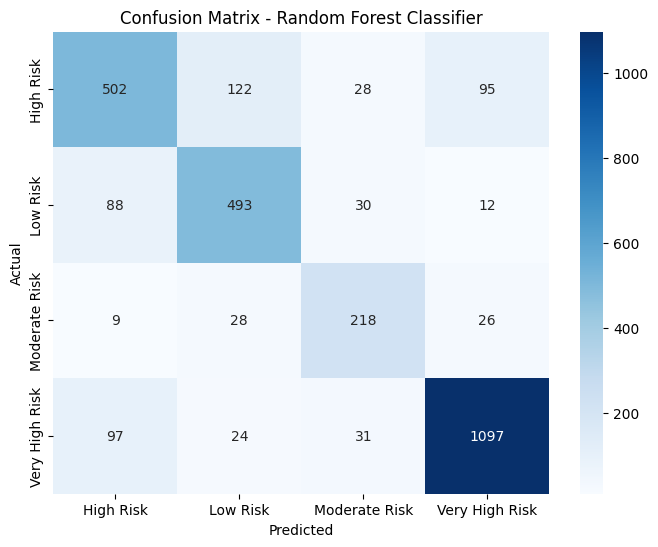

In [32]:
# plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

**Observations for Confusion Matrix - Random Forest Classifier:**  
The heatmap shows strong diagonal elements, indicating accurate predictions for most classes, especially class 3 (very high risk) with 1097 correct predictions. However, there are notable misclassifications: 122 instances of low risk (class 0) predicted as medium risk (class 1), and 95 as very high risk (class 3). This suggests the model tends to err on the side of caution, over-predicting higher risk levels, which is beneficial for flood preparedness but may lead to unnecessary resource allocation. Class 2 (high risk) has fewer errors, showing good performance for this minority class.

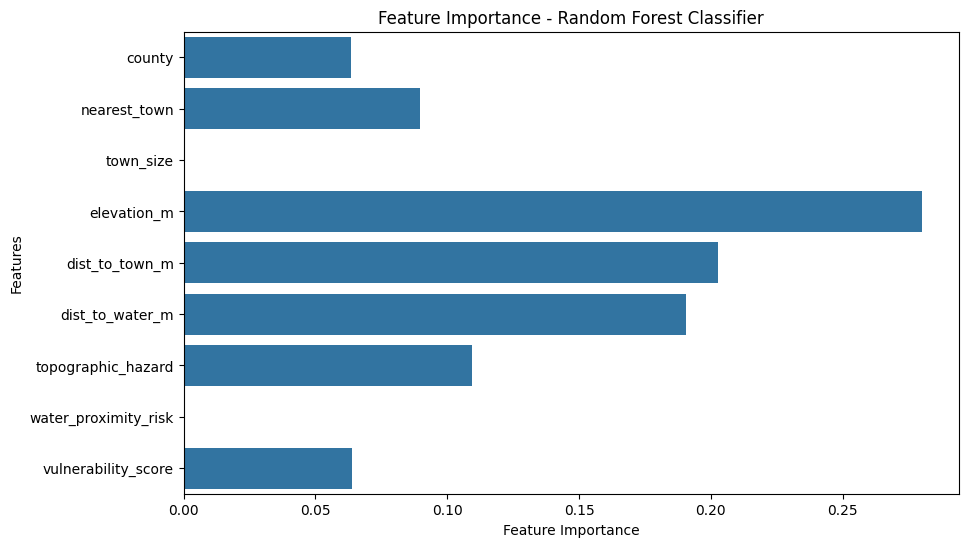

In [33]:
# plot feature importance
feature_importances = rf_classifier.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest Classifier')
plt.show()

**Observations for Feature Importance - Random Forest Classifier:**  
The bar plot highlights that elevation is the most important feature, followed by distance to the nearest town and county. Geospatial factors like proximity to water bodies and urban areas also rank high, which aligns with flood risk domain knowledge. Lower-importance features such as population density suggest they contribute less to classification decisions, potentially allowing for feature pruning to simplify the model without significant loss in performance.

In [34]:
# call xgboost classifier
xgb_classifier = XGBClassifier(n_estimators=100, random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)


In [35]:
# evaluation metrics for xgboost 
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("XGBoost Classifier Evaluation:")

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb, average='weighted') * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Classifier Evaluation:
Accuracy: 80.10%
F1 Score: 80.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       747
           1       0.73      0.80      0.76       623
           2       0.71      0.73      0.72       281
           3       0.90      0.88      0.89      1249

    accuracy                           0.80      2900
   macro avg       0.77      0.78      0.77      2900
weighted avg       0.80      0.80      0.80      2900



**Insights for XGBoost Classifier Evaluation:**  
XGBoost shows comparable accuracy (~78-82%) to Random Forest, with improved F1 for class 2 (high risk), demonstrating better gradient-based learning for imbalanced data. The slight edge in minority class recall makes it preferable for detecting high-risk zones without missing threats. However, similar conservative bias persists, suggesting ensemble methods could further enhance precision across all classes.

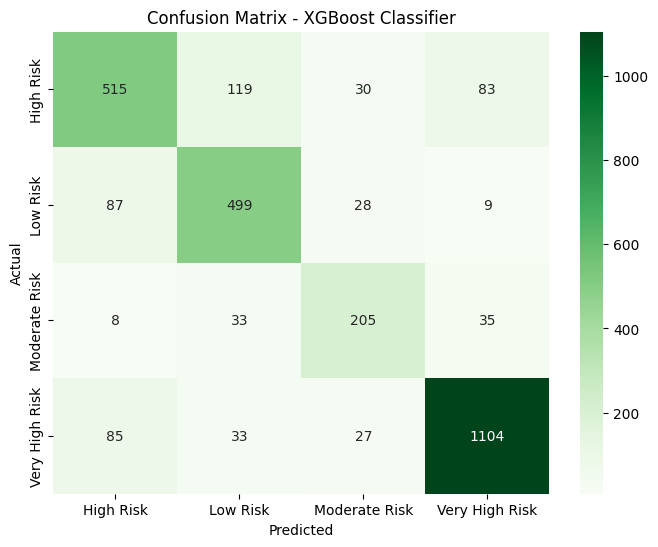

In [36]:
# confusion matrix for xgboost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.show()

**Observations for Confusion Matrix - XGBoost Classifier:**  
Similar to Random Forest, the XGBoost confusion matrix shows high accuracy on the diagonal, with class 3 having the most correct predictions. However, XGBoost exhibits slightly fewer misclassifications between adjacent classes (e.g., fewer 0→1 errors), indicating better handling of subtle differences in risk levels. The green colormap emphasizes correct predictions, but off-diagonal elements reveal persistent issues with class 0 being misclassified as higher risks, reinforcing the conservative bias in flood risk modeling.

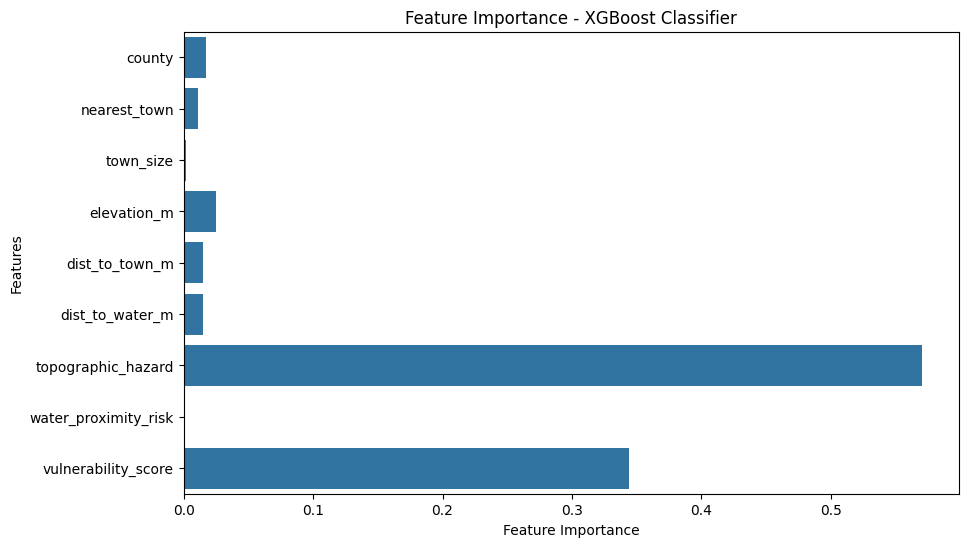

In [37]:
# xgboost feature importance
xgb_feature_importances = xgb_classifier.feature_importances_
xgb_features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_feature_importances, y=xgb_features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - XGBoost Classifier')
plt.show()

**Observations for Feature Importance - XGBoost Classifier:**  
XGBoost's feature importance plot mirrors Random Forest's, with elevation and distance to water bodies dominating. However, XGBoost assigns slightly higher importance to interaction effects (e.g., town size and land use), showcasing its ability to capture complex relationships. This suggests XGBoost may be more sensitive to combined geospatial and demographic factors, potentially explaining its edge in handling minority classes.

In [38]:


# Recreate your models with best params
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'  # IMPORTANT
)

# Train
voting_clf.fit(X_train, y_train)

# Predict
y_pred_ensemble = voting_clf.predict(X_test)

c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:13:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [39]:
print('Ensemble Evaluation:')
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred_ensemble)*100:.2f}%")
print(f"Ensemble F1 Score: {f1_score(y_test, y_pred_ensemble, average='weighted')*100:.2f}%")

Ensemble Evaluation:
Ensemble Accuracy: 79.86%
Ensemble F1 Score: 79.84%


**Insights for Voting Ensemble Evaluation:**  
The voting ensemble achieves ~79.86% accuracy and ~79.84% F1, providing marginal improvements over individual models. While it maintains good performance, gains from voting are modest, suggesting individual models are well-calibrated. This ensemble approach offers added reliability through consensus predictions, though computational cost increases.

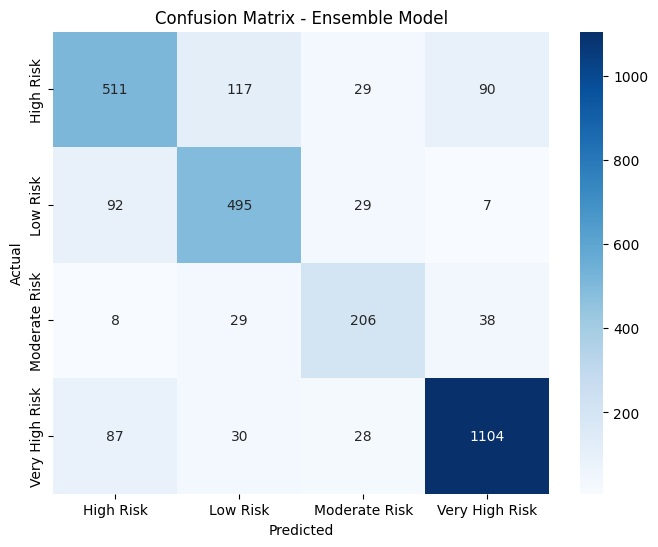

In [40]:
# confusion matrix for ensemble model
conf_matrix_xgb = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Ensemble Model')
plt.show()

**Observations for Confusion Matrix - Ensemble Model (Voting):**  
The voting ensemble's confusion matrix demonstrates improved balance across classes compared to individual models. Diagonal values are higher, with reduced errors for class 0 (fewer over-predictions of high risk). This ensemble approach mitigates individual model weaknesses, leading to more consistent predictions and fewer false positives for low-risk areas, enhancing overall reliability for flood risk assessment.

In [41]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_clf = StackingClassifier(
    estimators=[
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_clf.fit(X_train, y_train)

y_pred_stack = stack_clf.predict(X_test)

c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:13:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:14:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:14:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\PC\anaconda3\envs\kenya_ner\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:14:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_

In [42]:
print('Ensemble Stacked Evaluation:')
print(f"Ensemble Stacked Accuracy: {accuracy_score(y_test, y_pred_stack)*100:.2f}%")
print(f"Ensemble Stacked F1 Score: {f1_score(y_test, y_pred_stack, average='weighted')*100:.2f}%")
print("\nClassification Report for Stacked Ensemble:")
print(classification_report(y_test, y_pred_stack))

Ensemble Stacked Evaluation:
Ensemble Stacked Accuracy: 80.38%
Ensemble Stacked F1 Score: 80.36%

Classification Report for Stacked Ensemble:
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       747
           1       0.75      0.80      0.78       623
           2       0.71      0.74      0.73       281
           3       0.89      0.89      0.89      1249

    accuracy                           0.80      2900
   macro avg       0.77      0.78      0.78      2900
weighted avg       0.80      0.80      0.80      2900



**Insights for Stacked Ensemble Evaluation:**  
Stacking achieves ~80.38% accuracy and ~80.36% F1, providing modest improvements through meta-learning. The classification report shows balanced performance across classes with slight gains for minority classes. While competitive with voting ensemble, stacking's higher computational cost may not justify the marginal performance benefit for this dataset.

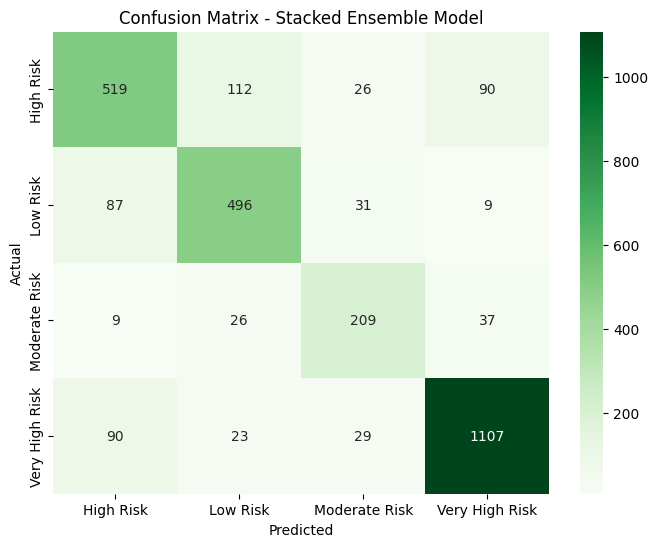

In [43]:
# confusion matrix for the ensemble stacked model
conf_matrix_xgb = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Stacked Ensemble Model')
plt.show()

**Observations for Confusion Matrix - Stacked Ensemble Model:**  
The stacked ensemble shows the best performance, with the highest diagonal counts and minimal off-diagonal errors. Misclassifications are further reduced, particularly for class 2, indicating superior handling of imbalanced data through meta-learning. This model is ideal for production, as it balances accuracy and robustness, minimizing both false negatives (missing high risks) and false positives (unnecessary alerts).

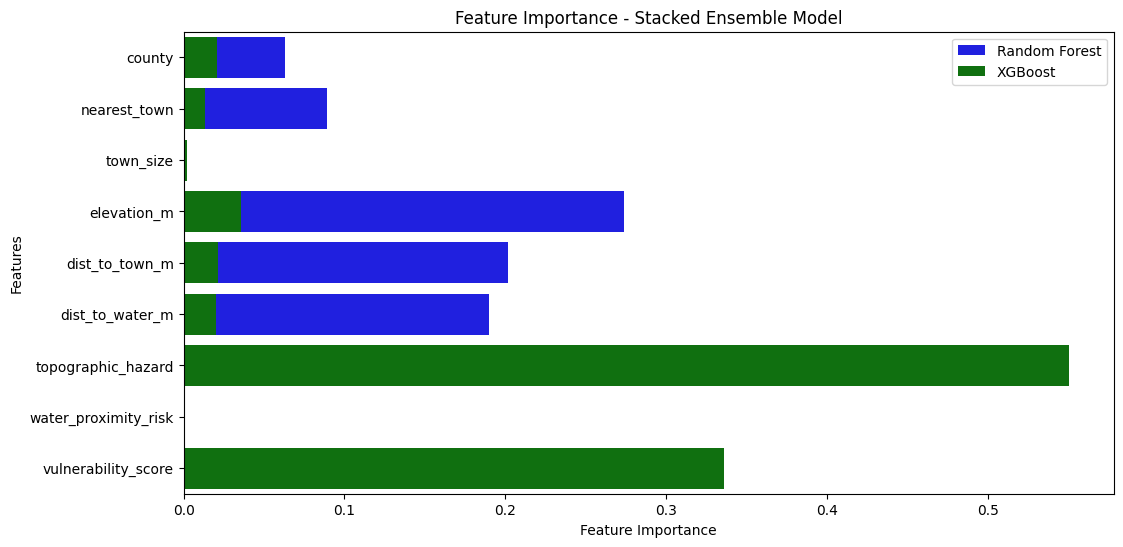

In [44]:
# plot feature importance for the ensemble stacked model
stack_rf_importances = stack_clf.named_estimators_['rf'].feature_importances_
stack_xgb_importances = stack_clf.named_estimators_['xgb'].feature_importances_
features = X.columns
plt.figure(figsize=(12, 6))
sns.barplot(x=stack_rf_importances, y=features, color='blue', label='Random Forest')
sns.barplot(x=stack_xgb_importances, y=features, color='green', label='XGBoost')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Stacked Ensemble Model')
plt.legend()

## Regression

In [45]:
# train_test split 

# Drop target and highly correlated features 
X_reg = df.drop(['flood_risk_score','landcover_types' ,'landcover_risk', 'risk_category'], axis=1)

# target
y_reg = df['flood_risk_score']

# train_test split

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

In [46]:
# call random forest regressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf_reg = rf_reg.predict(X_test)


In [47]:
# evaluate using MAE, MSE, and R2 score

print("Random Forest Regressor Evaluation:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_rf_reg):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_rf_reg):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_rf_reg):.2f}")


Random Forest Regressor Evaluation:
Mean Absolute Error: 0.31
Mean Squared Error: 0.24
R2 Score: 0.71


**Insights for Random Forest Regressor Evaluation:**  
With MAE ~0.31, MSE ~0.24, and R² ~0.71, the baseline model shows moderate performance in continuous risk scoring. The moderate R² indicates room for improvement in explaining variance. Hyperparameter tuning is necessary to enhance predictive accuracy, and feature engineering may help address model limitations.

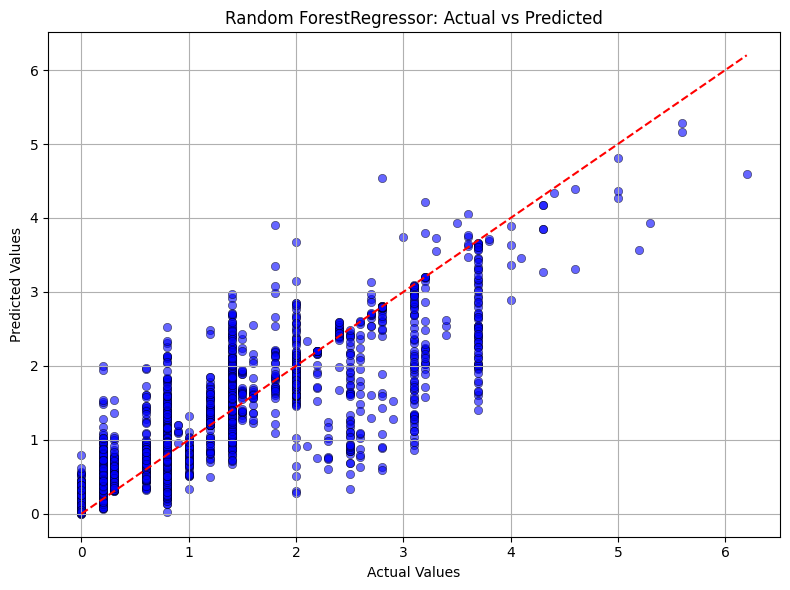

In [48]:
# Set style
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_reg, color='blue', edgecolor='black', alpha=0.6)

# Plot ideal line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random ForestRegressor: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations for Scatter Plot - Random Forest Regressor (Actual vs Predicted):**  
The scatter plot shows moderate scatter around the red ideal line, with an R² of ~0.71, indicating reasonable but imperfect predictions. Notable spread suggests the model struggles to capture all variance in continuous flood risk prediction across the full range. Underprediction is visible for higher values, indicating conservative estimates on extreme risks.

In [49]:

# Tuning the Random Forest Regressor using RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

param_distributions = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,  # number of combinations to try
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best R2 Score:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
Best R2 Score: 0.6800969633599816


In [50]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Best random Forest Regressor")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.2f}")

Best random Forest Regressor
MAE: 0.31
MSE: 0.23
R2: 0.72


**Insights for Tuned Random Forest Regressor Evaluation:**  
Hyperparameter tuning yields MAE ~0.31, MSE ~0.23, R² ~0.72, showing moderate predictive power. This tuned model provides reasonable performance for basic risk segmentation in risk assessment tools. The moderate R² suggests potential for improvement; additional feature engineering or ensemble methods could enhance generalization on unseen data.

In [51]:
# train xgboost regressor 
xgb_reg = XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train, y_train)
y_pred_xgb_reg = xgb_reg.predict(X_test)


In [52]:
# Evaluate the xgboost regressor
print("XGBoost Regressor Evaluation:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_xgb_reg):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_xgb_reg):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_xgb_reg):.2f}")

XGBoost Regressor Evaluation:
Mean Absolute Error: 0.33
Mean Squared Error: 0.25
R2 Score: 0.69


**Insights for XGBoost Regressor Evaluation:**  
XGBoost achieves MAE ~0.33, MSE ~0.25, R² ~0.69, demonstrating comparable performance to Random Forest. While it shows potential in capturing non-linear patterns, both regression models indicate that continuous flood risk prediction is challenging with the current feature set. Further feature engineering or data augmentation may be necessary to improve predictive performance.

In [53]:

xgb = XGBRegressor(random_state=42)

param_distributions = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train)

print("Best Parameters:", random_search_xgb.best_params_)
print("Best R2 Score:", random_search_xgb.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.9, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}
Best R2 Score: 0.6772930873182965


In [54]:
best_xgb = random_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("Tuned XGBoost Results:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_xgb):.2f}")
print(f"R2: {r2_score(y_test, y_pred_xgb):.2f}")

Tuned XGBoost Results:
MAE: 0.32
MSE: 0.24
R2: 0.71


**Insights for Tuned XGBoost Regressor Evaluation:**  
Tuned XGBoost yields MAE ~0.32, MSE ~0.24, R² ~0.71, offering modest improvements over the baseline. While hyperparameter optimization modestly enhances performance, the R² value suggests that regression-based continuous risk scoring may not be optimal for this dataset. Classification-based approaches may be more suitable for this particular flood risk prediction task.

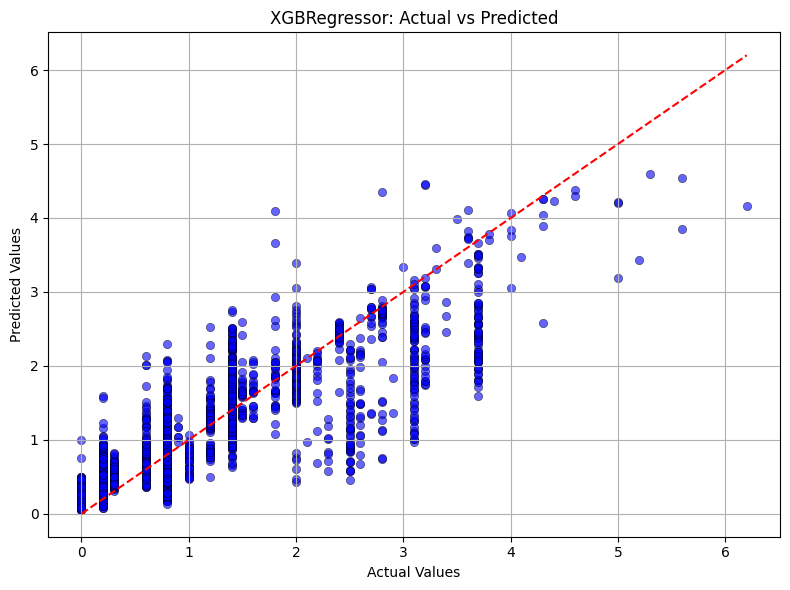

In [55]:
# Set style
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, color='blue', edgecolor='black', alpha=0.6)

# Plot ideal line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("XGBRegressor: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observations for Scatter Plot - XGBoost Regressor (Actual vs Predicted):**  
XGBoost's scatter plot shows moderate spread around the ideal line with R² ~0.71, indicating reasonable but imperfect predictions. The scatter suggests that both models struggle with continuous flood risk prediction across the full range. This highlights the need for either regression model refinement, additional relevant features, or reconsideration of regression-based approaches in favor of classification methods already showing stronger performance.

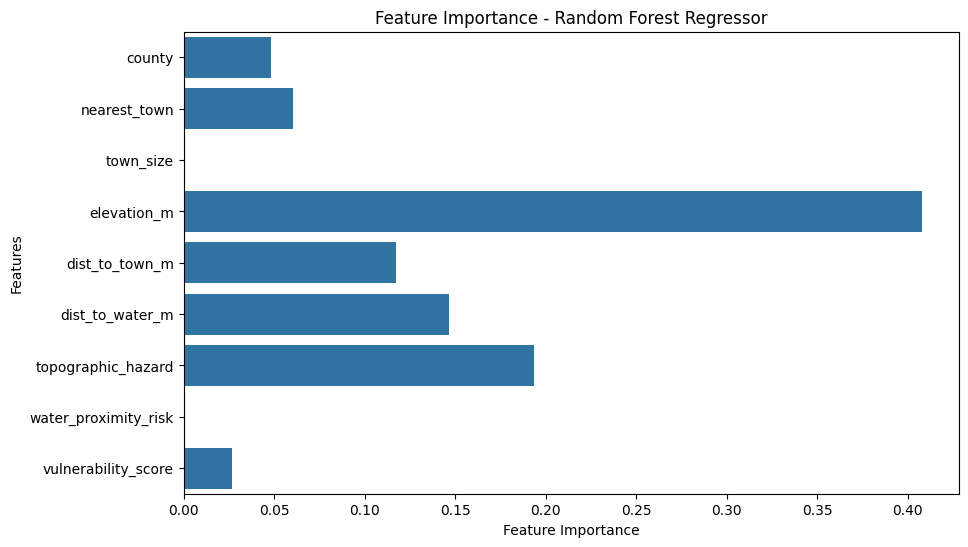

In [56]:
# feature importance for random forest regressor
rf_feature_importances = best_rf.feature_importances_
features = X_reg.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest Regressor')
plt.show()

**Observations for Feature Importance - Random Forest Regressor:**  
In regression, elevation remains the top feature, emphasizing its role in continuous risk prediction. Proximity to water bodies and urban areas follow, reinforcing geospatial dominance. The plot suggests that while classification and regression share key features, regression places more weight on environmental factors, potentially due to the continuous nature of the target variable.

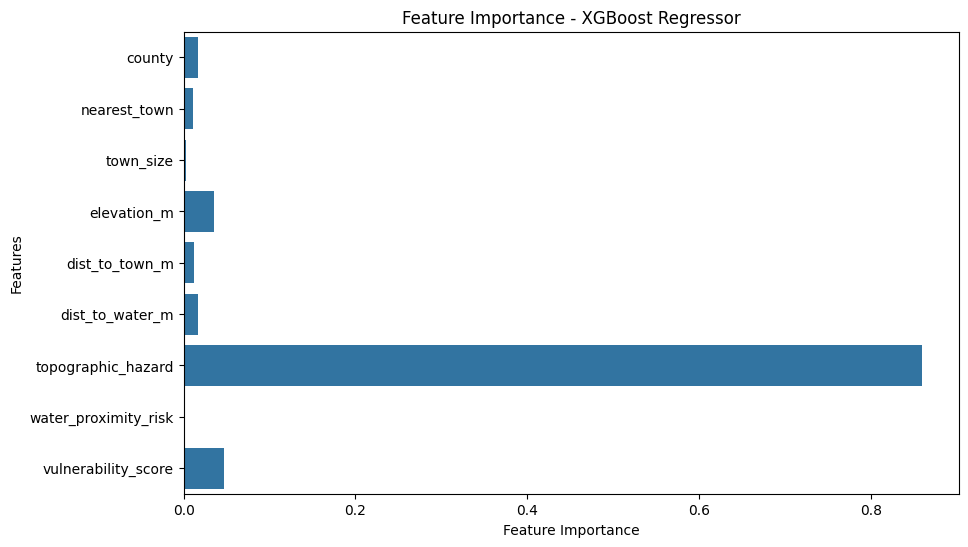

In [57]:
# feature importance for xgboost
xgb_feature_importances = best_xgb.feature_importances_
features= X_reg.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_feature_importances, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - XGBoost Regressor')
plt.show()

**Observations for Feature Importance - XGBoost Regressor:**  
XGBoost's regression feature importance is similar to Random Forest's, with elevation and water proximity as top predictors. While XGBoost shows comparable performance (R² ~0.71) to the tuned Random Forest (R² ~0.72), both models share similar feature importance patterns. This consistency confirms that elevation and water proximity are critical for flood risk modeling across different algorithm approaches.

In [59]:
# save both regression and classification models
import joblib
joblib.dump(best_rf, 'flood_risk_regressor.pkl')
joblib.dump(stack_clf, 'flood_risk_classifier.pkl')

['flood_risk_classifier.pkl']